Conectando ao Pandas

In [1]:
import pandas as pd

In [2]:
path = 'dados/1-SEEG10_GERAL-BR_UF_2022.10.27-FINAL-SITE.xlsx'
dados = pd.read_excel(path, sheet_name='GEE Estados')

c:\Users\logistica.wms\AppData\Local\Programs\Python\Python314\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [3]:
df = pd.DataFrame(dados)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103312 entries, 0 to 103311
Data columns (total 63 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Nível 1 - Setor             103312 non-null  str    
 1   Nível 2                     103312 non-null  str    
 2   Nível 3                     103253 non-null  str    
 3   Nível 4                     90920 non-null   str    
 4   Nível 5                     100788 non-null  str    
 5   Nível 6                     97691 non-null   str    
 6   Emissão / Remoção / Bunker  103312 non-null  str    
 7   Gás                         103312 non-null  str    
 8   Estado                      97374 non-null   str    
 9   Atividade Econômica         102076 non-null  str    
 10  Produto                     37413 non-null   str    
 11  1970                        103312 non-null  float64
 12  1971                        103312 non-null  float64
 13  1972                     

In [4]:
colunas_info = list(df.loc[:, 'Nível 1 - Setor':'Produto'].columns)
colunas_valores = list(df.loc[:, 1970:2021].columns)

In [5]:
df.melt(id_vars=        colunas_info, 
        value_vars=     colunas_valores, 
        var_name=       'Ano', 
        value_name=     'Emissão')

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Emissão / Remoção / Bunker,Gás,Estado,Atividade Econômica,Produto,Ano,Emissão
0,Processos Industriais,Indústria Química,Produção de ABS,NaN,NaN,NaN,Emissão,COVNM (t),SP,OUTRA_IND,NaN,1970,0.0
1,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,N2O (t),SP,OUTRA_IND,NaN,1970,6210.0
2,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,CO (t),SP,OUTRA_IND,NaN,1970,368.0
3,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,NOx (t),SP,OUTRA_IND,NaN,1970,115.0
4,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,CO2e (t) GWP-AR2,SP,OUTRA_IND,NaN,1970,1925100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5372219,Mudança de Uso da Terra e Floresta,Queimadas Não Associadas a Desmatamento,Pantanal,NaN,NaN,NaN,Emissão NCI,CO2e (t) GTP-AR6,BR,NaN,NaN,2021,0.0
5372220,Mudança de Uso da Terra e Floresta,Queimadas Não Associadas a Desmatamento,Pantanal,NaN,NaN,NaN,Emissão NCI,CO2e (t) GWP-AR2,BR,NaN,NaN,2021,0.0
5372221,Mudança de Uso da Terra e Floresta,Queimadas Não Associadas a Desmatamento,Pantanal,NaN,NaN,NaN,Emissão NCI,CO2e (t) GWP-AR4,BR,NaN,NaN,2021,0.0
5372222,Mudança de Uso da Terra e Floresta,Queimadas Não Associadas a Desmatamento,Pantanal,NaN,NaN,NaN,Emissão NCI,CO2e (t) GWP-AR5,BR,NaN,NaN,2021,0.0


In [6]:
df = df.melt(id_vars=   colunas_info, 
        value_vars=     colunas_valores, 
        var_name=       'Ano', 
        value_name=     'Emissão')

In [7]:
emissoes_por_gas = df.groupby(['Gás']).sum(numeric_only=True).sort_values(by='Emissão', ascending=False)
emissoes_por_gas

,Emissão
Gás,
CO2e (t) GWP-AR5,7.048576e+10
CO2e (t) GWP-AR6,6.999228e+10
CO2e (t) GWP-AR4,6.882629e+10
CO2e (t) GWP-AR2,6.584700e+10
CO2e (t) GTP-AR4,5.193173e+10
CO2e (t) GTP-AR2,5.193173e+10
CO2e (t) GTP-AR6,5.094025e+10
CO2e (t) GTP-AR5,5.027836e+10
CO2 (t),4.153325e+10


In [9]:
df.groupby(['Gás']).groups

C:\Users\logistica.wms\AppData\Local\Temp\ipykernel_11180\2646761887.py:1: Pandas4Warning: In a future version, the keys of `groups` will be a tuple with a single element, e.g. (Gás,) , instead of a scalar, e.g. Gás, when grouping by a list with a single element. Use ``df.groupby(by='a').groups`` instead of ``df.groupby(by=['a']).groups`` to avoid this warning
  df.groupby(['Gás']).groups


{'C2F6 (t)': [410, 411, 412, 425, 426, 427, 103722, 103723, 103724, 103737, 103738, 103739, 207034, 207035, 207036, 207049, 207050, 207051, 310346, 310347, 310348, 310361, 310362, 310363, 413658, 413659, 413660, 413673, 413674, 413675, 516970, 516971, 516972, 516985, 516986, 516987, 620282, 620283, 620284, 620297, 620298, 620299, 723594, 723595, 723596, 723609, 723610, 723611, 826906, 826907, 826908, 826921, 826922, 826923, 930218, 930219, 930220, 930233, 930234, 930235, 1033530, 1033531, 1033532, 1033545, 1033546, 1033547, 1136842, 1136843, 1136844, 1136857, 1136858, 1136859, 1240154, 1240155, 1240156, 1240169, 1240170, 1240171, 1343466, 1343467, 1343468, 1343481, 1343482, 1343483, 1446778, 1446779, 1446780, 1446793, 1446794, 1446795, 1550090, 1550091, 1550092, 1550105, 1550106, 1550107, 1653402, 1653403, 1653404, 1653417, ...], 'CF4 (t)': [407, 408, 409, 422, 423, 424, 103719, 103720, 103721, 103734, 103735, 103736, 207031, 207032, 207033, 207046, 207047, 207048, 310343, 310344, 3103

<Axes: ylabel='Gás'>

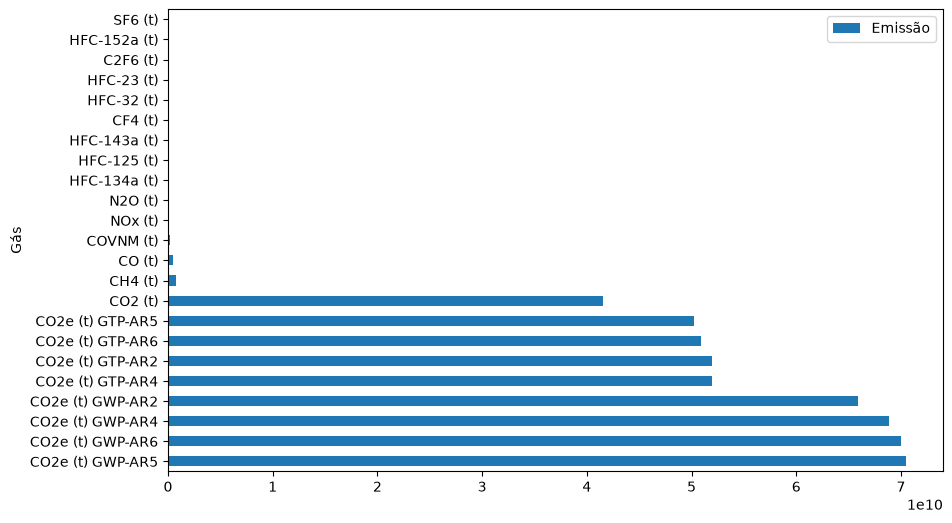

In [8]:
emissoes_por_gas.plot(kind='barh', figsize=(10,6))

Faça um agrupamento de dados com base na coluna "Nível 1 - Setor" para visualizar o dicionário contendo as chaves de grupos formados e a lista de índices de cada grupo.

In [10]:
df.groupby(['Nível 1 - Setor']).groups

C:\Users\logistica.wms\AppData\Local\Temp\ipykernel_27624\2641989849.py:1: Pandas4Warning: In a future version, the keys of `groups` will be a tuple with a single element, e.g. (Nível 1 - Setor,) , instead of a scalar, e.g. Nível 1 - Setor, when grouping by a list with a single element. Use ``df.groupby(by='a').groups`` instead of ``df.groupby(by=['a']).groups`` to avoid this warning
  df.groupby(['Nível 1 - Setor']).groups


{'Agropecuária': [1137, 1138, 1139, 1140, 1141, 1142, 1143, 1144, 1145, 1146, 1147, 1148, 1149, 1150, 1151, 1152, 1153, 1154, 1155, 1156, 1157, 1158, 1159, 1160, 1161, 1162, 1163, 1164, 1165, 1166, 1167, 1168, 1169, 1170, 1171, 1172, 1173, 1174, 1175, 1176, 1177, 1178, 1179, 1180, 1181, 1182, 1183, 1184, 1185, 1186, 1187, 1188, 1189, 1190, 1191, 1192, 1193, 1194, 1195, 1196, 1197, 1198, 1199, 1200, 1201, 1202, 1203, 1204, 1205, 1206, 1207, 1208, 1209, 1210, 1211, 1212, 1213, 1214, 1215, 1216, 1217, 1218, 1219, 1220, 1221, 1222, 1223, 1224, 1225, 1226, 1227, 1228, 1229, 1230, 1231, 1232, 1233, 1234, 1235, 1236, ...], 'Energia': [24735, 24736, 24737, 24738, 24739, 24740, 24741, 24742, 24743, 24744, 24745, 24746, 24747, 24748, 24749, 24750, 24751, 24752, 24753, 24754, 24755, 24756, 24757, 24758, 24759, 24760, 24761, 24762, 24763, 24764, 24765, 24766, 24767, 24768, 24769, 24770, 24771, 24772, 24773, 24774, 24775, 24776, 24777, 24778, 24779, 24780, 24781, 24782, 24783, 24784, 24785, 24786, 

Faça um agrupamento de dados com base na coluna "Nível 1 - Setor" e localize os dados do grupo "Agropecuária".

In [16]:
df[df['Nível 1 - Setor'] == 'Agropecuária'].head(5)

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Emissão / Remoção / Bunker,Gás,Estado,Atividade Econômica,Produto,Ano,Emissão
1137,Agropecuária,Cultivo de Arroz,Diretas,Outros,Vegetal,Arroz,Emissão,CH4 (t),AC,AGR,ALIM_BEBIDAS,1970,0.000000
1138,Agropecuária,Cultivo de Arroz,Diretas,Outros,Vegetal,Arroz,Emissão,CH4 (t),AL,AGR,ALIM_BEBIDAS,1970,2050.445805
1139,Agropecuária,Cultivo de Arroz,Diretas,Outros,Vegetal,Arroz,Emissão,CH4 (t),AM,AGR,ALIM_BEBIDAS,1970,0.000000
1140,Agropecuária,Cultivo de Arroz,Diretas,Outros,Vegetal,Arroz,Emissão,CH4 (t),AP,AGR,ALIM_BEBIDAS,1970,0.000000
1141,Agropecuária,Cultivo de Arroz,Diretas,Outros,Vegetal,Arroz,Emissão,CH4 (t),BA,AGR,ALIM_BEBIDAS,1970,466.934705


Faça um agrupamento de dados com base na coluna "Nível 1 - Setor" para identificar a média de emissão de cada setor no ano de 2021.

In [14]:
df[df['Ano'] == 2021].groupby('Nível 1 - Setor').mean(numeric_only=True)

,Emissão
Nível 1 - Setor,
Agropecuária,53082.725943
Energia,75120.049185
Mudança de Uso da Terra e Floresta,196843.405133
Processos Industriais,787101.255789
Resíduos,106106.723386


Faça um agrupamento de dados com base na coluna "Nível 1 - Setor" para identificar a soma de emissão de cada setor. Ordene os dados da maior para menor emissão.

In [15]:
df[df['Ano'] == 2021].groupby('Nível 1 - Setor').sum(numeric_only=True).sort_values(by='Emissão', ascending=False)

,Emissão
Nível 1 - Setor,
Mudança de Uso da Terra e Floresta,4.340791e+09
Energia,3.959503e+09
Agropecuária,1.252646e+09
Processos Industriais,8.949341e+08
Resíduos,4.049033e+08


In [9]:
gas_por_setor = df.groupby(['Gás', 'Nível 1 - Setor'])[['Emissão']].sum()

In [10]:
gas_por_setor

Emissão
Gás      Nível 1 - Setor                                 
C2F6 (t) Processos Industriais               5.765018e+02
CF4 (t)  Processos Industriais               7.135481e+03
CH4 (t)  Agropecuária                        5.928481e+08
         Energia                             3.432620e+07
         Mudança de Uso da Terra e Floresta  9.484303e+07
...                                                   ...
N2O (t)  Resíduos                            2.764127e+05
NOx (t)  Agropecuária                        2.602719e+06
         Energia                             1.008308e+08
         Processos Industriais               3.546360e+06
SF6 (t)  Processos Industriais               4.705800e+02

[72 rows x 1 columns]

In [23]:
dados2 = df.groupby(['Ano', 'Gás'])[['Emissão']].mean().reset_index()

In [24]:
dados2

,Ano,Gás,Emissão
0,1970,C2F6 (t),0.232610
1,1970,CF4 (t),3.557421
2,1970,CH4 (t),1468.366197
3,1970,CO (t),2154.429254
4,1970,CO2 (t),16208.866464
...,...,...,...
1191,2021,HFC-23 (t),0.000000
1192,2021,HFC-32 (t),261.100000
1193,2021,N2O (t),119.172531
1194,2021,NOx (t),744.579232


In [25]:
dados2 = dados2.pivot_table(index='Ano', columns='Gás', values='Emissão')

In [26]:
dados2.head(5)

Gás,C2F6 (t),CF4 (t),CH4 (t),CO (t),CO2 (t),CO2e (t) GTP-AR2,CO2e (t) GTP-AR4,CO2e (t) GTP-AR5,CO2e (t) GTP-AR6,CO2e (t) GWP-AR2,...,COVNM (t),HFC-125 (t),HFC-134a (t),HFC-143a (t),HFC-152a (t),HFC-23 (t),HFC-32 (t),N2O (t),NOx (t),SF6 (t)
Ano,,,,,,,,,,,,,,,,,,,,,
1970,0.232610,3.557421,1468.366197,2154.429254,16208.866464,18862.703799,18862.703799,17370.674172,17921.680291,31972.459540,...,741.692873,0.0,0.0,0.0,0.0,0.0,0.0,31.590338,159.944249,0.0
1971,0.334611,5.117360,1522.749052,2258.483712,18146.100667,20331.726520,20331.726520,18786.502412,19360.117065,33918.077574,...,729.773925,0.0,0.0,0.0,0.0,0.0,0.0,32.564894,177.219333,0.0
1972,0.404684,6.189025,1581.855297,2417.704589,19877.907343,21811.052503,21811.052503,20194.514777,20791.408670,35933.295351,...,773.908363,0.0,0.0,0.0,0.0,0.0,0.0,34.265347,195.786087,0.0
1973,0.463147,7.083136,1639.621403,2594.007500,23040.103307,24008.339911,24008.339911,22338.262259,22958.289918,38637.085426,...,796.232223,0.0,0.0,0.0,0.0,0.0,0.0,35.225461,217.153952,0.0
1974,0.471026,7.203619,1701.513896,2679.348234,25101.967674,25703.767093,25703.767093,23959.827151,24608.023330,40897.425131,...,1023.881477,0.0,0.0,0.0,0.0,0.0,0.0,37.043361,247.348600,0.0


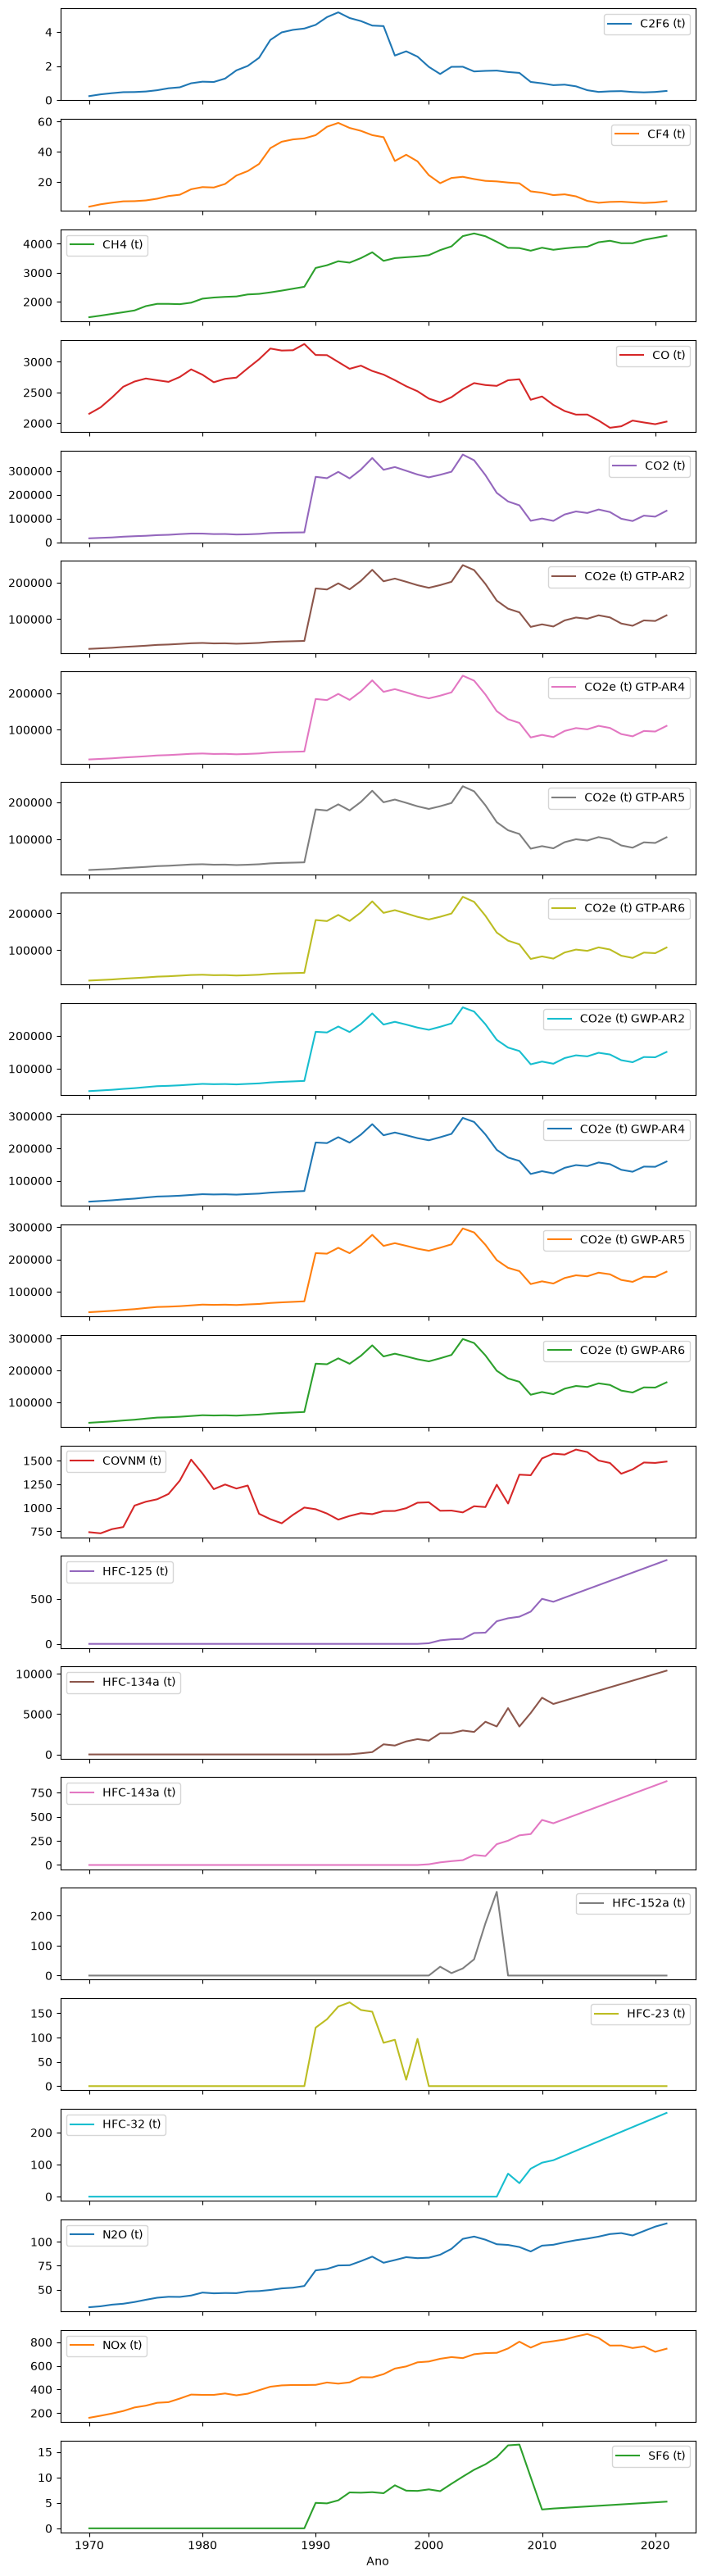

In [19]:
dados2.plot(subplots=True, figsize=(10,40));

Uma das tarefas passadas pela equipe de supervisão do órgão ambiental era de encontrar a emissão média de cada gás por ano

In [29]:
dados.head(5)

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Emissão / Remoção / Bunker,Gás,Estado,Atividade Econômica,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Processos Industriais,Indústria Química,Produção de ABS,NaN,NaN,NaN,Emissão,COVNM (t),SP,OUTRA_IND,...,897.600,897.600,897.600,897.600,897.600,897.600,897.600,897.600,897.600,897.600
1,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,N2O (t),SP,OUTRA_IND,...,130.000,130.000,130.000,130.000,130.000,130.000,130.000,130.000,130.000,130.000
2,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,CO (t),SP,OUTRA_IND,...,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576
3,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,NOx (t),SP,OUTRA_IND,...,431.430,431.430,431.430,431.430,431.430,431.430,431.430,431.430,431.430,431.430
4,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,CO2e (t) GWP-AR2,SP,OUTRA_IND,...,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000


In [30]:
dados3 = df.groupby(['Ano', 'Atividade Econômica'])[['Emissão']].mean().reset_index()

In [32]:
dados3 = dados3.pivot_table(index='Ano', columns='Atividade Econômica', values='Emissão')

array([<Axes: xlabel='Ano'>, <Axes: xlabel='Ano'>, <Axes: xlabel='Ano'>,
       <Axes: xlabel='Ano'>, <Axes: xlabel='Ano'>, <Axes: xlabel='Ano'>,
       <Axes: xlabel='Ano'>, <Axes: xlabel='Ano'>, <Axes: xlabel='Ano'>,
       <Axes: xlabel='Ano'>, <Axes: xlabel='Ano'>, <Axes: xlabel='Ano'>,
       <Axes: xlabel='Ano'>, <Axes: xlabel='Ano'>, <Axes: xlabel='Ano'>],
      dtype=object)

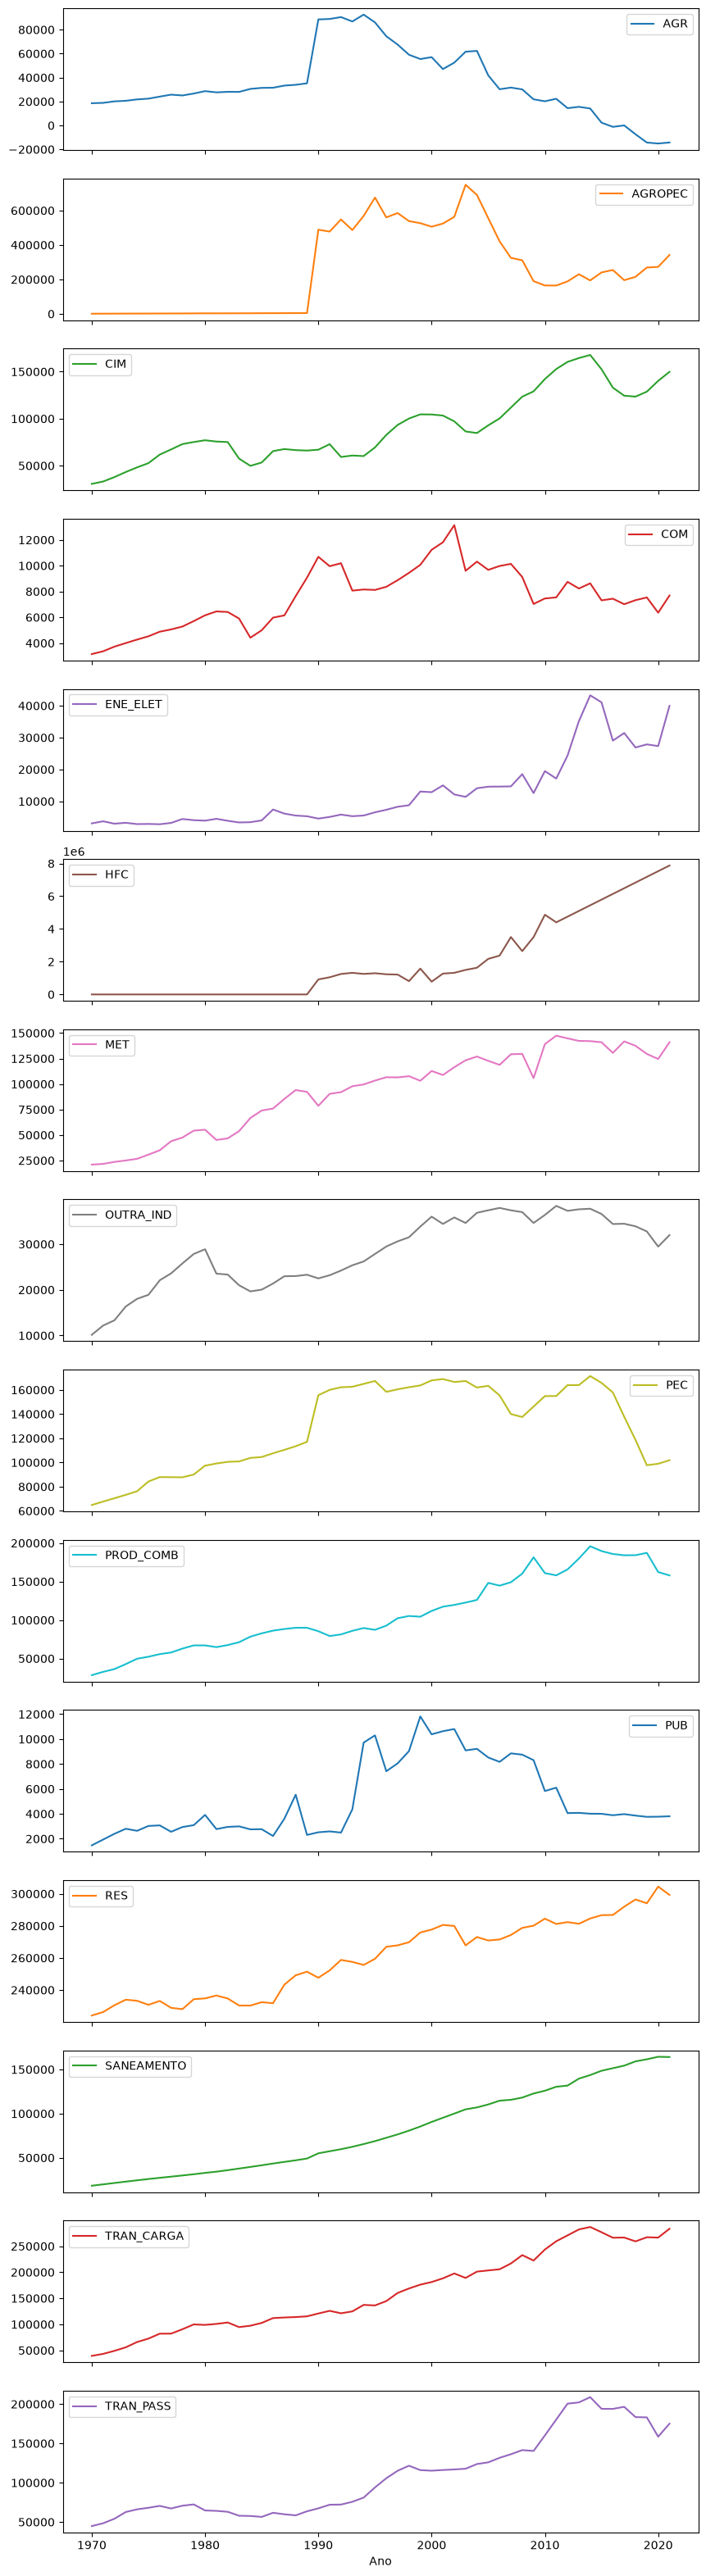

In [33]:
dados3.plot(subplots=True, figsize=(10,40))